<a href="https://colab.research.google.com/github/aum1107/MAJOR-PROJECT/blob/main/property.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost folium

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

import folium

from IPython.display import display

In [10]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

file_path = "/content/drive/MyDrive/real_estate_advisor_dataset_augmented.csv"
df = pd.read_csv(file_path)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,property_id,latitude,longitude,area_sqft,bedrooms,bathrooms,property_age_years,school_count_3km,hospital_count_3km,metro_distance_km,nearest_school_km,nearest_hospital_km,crime_rate_index,monthly_rent,price,property_type,locality_name,parking_spaces,shopping_malls_3km,nearest_shopping_km
0,P001,26.706181,88.481653,1476,4,3,25,5,4,6.41,0.43,0.44,0.60,56508,7508950,Independent House,Koramangala,0,5,0.35
1,P002,26.792607,88.347912,1591,3,1,18,1,4,9.65,1.32,1.19,0.35,43941,7480950,Penthouse,Koramangala,0,5,2.70
2,P003,26.759799,88.328979,646,2,1,18,3,3,11.75,2.41,0.13,0.47,37165,3103450,Apartment,Whitefield,2,5,2.75
3,P004,26.739799,88.397891,3470,5,1,20,11,3,10.11,2.26,2.47,0.72,9667,16415250,Independent House,Koramangala,1,5,3.22
4,P005,26.673403,88.497130,3303,5,2,4,10,4,10.43,0.26,0.47,0.83,34213,15597850,Independent House,Electronic City,1,4,3.66


In [ ]:
df.head()

,property_id,latitude,longitude,area_sqft,bedrooms,bathrooms,property_age_years,school_count_3km,hospital_count_3km,metro_distance_km,nearest_school_km,nearest_hospital_km,crime_rate_index,monthly_rent,price,property_type,locality_name,parking_spaces,shopping_malls_3km,nearest_shopping_km
0,P001,26.706181,88.481653,1476,4,3,25,5,4,6.41,0.43,0.44,0.60,56508,7508950,Independent House,Koramangala,0,5,0.35
1,P002,26.792607,88.347912,1591,3,1,18,1,4,9.65,1.32,1.19,0.35,43941,7480950,Penthouse,Koramangala,0,5,2.70
2,P003,26.759799,88.328979,646,2,1,18,3,3,11.75,2.41,0.13,0.47,37165,3103450,Apartment,Whitefield,2,5,2.75
3,P004,26.739799,88.397891,3470,5,1,20,11,3,10.11,2.26,2.47,0.72,9667,16415250,Independent House,Koramangala,1,5,3.22
4,P005,26.673403,88.497130,3303,5,2,4,10,4,10.43,0.26,0.47,0.83,34213,15597850,Independent House,Electronic City,1,4,3.66


In [ ]:
print("="*50)
print("DATASET INFORMATION")
print("="*50)

print(df.info())

print("\nMissing Values\n")

print(df.isnull().sum())

print("\nStatistical Summary\n")

print(df.describe())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          150 non-null    object 
 1   latitude             150 non-null    float64
 2   longitude            150 non-null    float64
 3   area_sqft            150 non-null    int64  
 4   bedrooms             150 non-null    int64  
 5   bathrooms            150 non-null    int64  
 6   property_age_years   150 non-null    int64  
 7   school_count_3km     150 non-null    int64  
 8   hospital_count_3km   150 non-null    int64  
 9   metro_distance_km    150 non-null    float64
 10  nearest_school_km    150 non-null    float64
 11  nearest_hospital_km  150 non-null    float64
 12  crime_rate_index     150 non-null    float64
 13  monthly_rent         150 non-null    int64  
 14  price                150 non-null    int64  
 15  property_type       

In [ ]:
print("="*50)
print("PROPERTY TYPES")
print("="*50)

print(df["property_type"].value_counts())

PROPERTY TYPES
property_type
Penthouse            46
Villa                36
Independent House    34
Apartment            34
Name: count, dtype: int64


In [ ]:
print("="*50)
print("LOCALITIES")
print("="*50)

print(df["locality_name"].value_counts())

LOCALITIES
locality_name
Whitefield         24
Jayanagar          22
Koramangala        21
Indiranagar        20
Marathahalli       18
Electronic City    16
Yelahanka          15
HSR Layout         14
Name: count, dtype: int64


In [ ]:
features = [

    "latitude",

    "longitude",

    "area_sqft",

    "bedrooms",

    "bathrooms",

    "property_age_years",

    "school_count_3km",

    "hospital_count_3km",

    "metro_distance_km",

    "crime_rate_index",

    "parking_spaces",

    "shopping_malls_3km"

]

X = df[features]

y = df["price"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

Training Data : (120, 12)
Testing Data : (30, 12)


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=6,

    random_state=42

)

model.fit(

    X_train,

    y_train

)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
from sklearn.metrics import mean_absolute_error

prediction = model.predict(X_test)

mae = mean_absolute_error(

    y_test,

    prediction

)

print("="*50)

print("MODEL PERFORMANCE")

print("="*50)

print("MAE :", round(mae))

MODEL PERFORMANCE
MAE : 373365


In [ ]:
print("="*50)
print("PRICE PREDICTION")
print("="*50)

property_id = input("Enter Property ID : ")

property_data = df[

    df["property_id"] == property_id

]

if len(property_data) == 0:

    print("Property Not Found")

else:

    actual_price = property_data["price"].values[0]

    predicted_price = model.predict(

        property_data[features]

    )[0]

    print()

    print("Property :", property_id)

    print()

    print("Actual Price : ₹", round(actual_price))

    print("Predicted Price : ₹", round(predicted_price))

    print()

    print("Difference : ₹",

          abs(round(actual_price-predicted_price)))

PRICE PREDICTION
Enter Property ID : P120

Property : P120

Actual Price : ₹ 12355300
Predicted Price : ₹ 12354066

Difference : ₹ 1234


In [ ]:
# ==========================================
# INVESTMENT SCORE
# ==========================================

def calculate_investment_score(row):

    score = 50

    # Positive Factors
    score += row["school_count_3km"] * 2
    score += row["hospital_count_3km"] * 3
    score += row["shopping_malls_3km"] * 2
    score += row["parking_spaces"] * 2

    # Metro Bonus
    if row["metro_distance_km"] <= 1:
        score += 10
    elif row["metro_distance_km"] <= 2:
        score += 5

    # Crime Penalty
    score -= row["crime_rate_index"] * 20

    return round(score,2)

df["investment_score"] = df.apply(calculate_investment_score, axis=1)

print("✅ Investment Score Created")

✅ Investment Score Created


In [ ]:
# ==========================================
# RENTAL YIELD
# ==========================================

df["rental_yield"] = (
    df["monthly_rent"] * 12
    / df["price"]
) * 100

df["rental_yield"] = df["rental_yield"].round(2)

print("✅ Rental Yield Created")

✅ Rental Yield Created


In [ ]:
# ==========================================
# FAMILY SCORE
# ==========================================

def calculate_family_score(row):

    score = 50

    score += row["school_count_3km"] * 5

    score += row["hospital_count_3km"] * 4

    score += row["shopping_malls_3km"] * 2

    if row["crime_rate_index"] < 0.3:
        score += 20
    elif row["crime_rate_index"] < 0.5:
        score += 10

    return round(score,2)

df["family_score"] = df.apply(
    calculate_family_score,
    axis=1
)

print("✅ Family Score Created")

✅ Family Score Created


In [ ]:
# ==========================================
# FUTURE GROWTH SCORE
# ==========================================

growth = []

for _, row in df.iterrows():

    score = 50

    if row["metro_distance_km"] <= 1:
        score += 20

    elif row["metro_distance_km"] <= 2:
        score += 10

    score += row["shopping_malls_3km"]

    score += row["hospital_count_3km"]

    growth.append(score)

df["future_growth_score"] = growth

print("✅ Future Growth Score Created")

✅ Future Growth Score Created


In [ ]:
# ==========================================
# SAFETY SCORE
# ==========================================

def calculate_safety_score(row):
    score = 100 # Start with a high score

    # Penalize based on crime rate index
    score -= row["crime_rate_index"] * 50

    # Ensure score doesn't go below 0
    return round(max(0, score),2)

df["safety_score"] = df.apply(calculate_safety_score, axis=1)

print("✅ Safety Score Created")

✅ Safety Score Created


In [ ]:
# ==========================================
# OVERALL AI SCORE
# ==========================================

df["overall_ai_score"] = (

    df["investment_score"] * 0.35 +

    df["family_score"] * 0.25 +

    df["safety_score"] * 0.20 +

    df["future_growth_score"] * 0.10 +

    df["rental_yield"] * 2

)

df["overall_ai_score"] = df["overall_ai_score"].round(2)

print("✅ Overall AI Score Created")

✅ Overall AI Score Created


In [ ]:
df.head()

,property_id,latitude,longitude,area_sqft,bedrooms,bathrooms,property_age_years,school_count_3km,hospital_count_3km,metro_distance_km,...,locality_name,parking_spaces,shopping_malls_3km,nearest_shopping_km,investment_score,rental_yield,family_score,future_growth_score,safety_score,overall_ai_score
0,P001,26.706181,88.481653,1476,4,3,25,5,4,6.41,...,Koramangala,0,5,0.35,70.0,9.03,101,59,70.0,87.71
1,P002,26.792607,88.347912,1591,3,1,18,1,4,9.65,...,Koramangala,0,5,2.70,67.0,7.05,91,59,82.5,82.70
2,P003,26.759799,88.328979,646,2,1,18,3,3,11.75,...,Whitefield,2,5,2.75,69.6,14.37,97,58,76.5,98.45
3,P004,26.739799,88.397891,3470,5,1,20,11,3,10.11,...,Koramangala,1,5,3.22,78.6,0.71,127,58,64.0,79.28
4,P005,26.673403,88.497130,3303,5,2,4,10,4,10.43,...,Electronic City,1,4,3.66,75.4,2.63,124,58,58.5,80.15


In [ ]:
# ==========================================
# PROPERTY REPORT
# ==========================================

property_id = input("Enter Property ID : ")

property_data = df[
    df["property_id"] == property_id
]

if property_data.empty:

    print("❌ Property Not Found")

else:

    row = property_data.iloc[0]

    print("\n")
    print("="*55)
    print("🏠 PROPERTY REPORT")
    print("="*55)

    print("Property ID        :", row["property_id"])
    print("Locality           :", row["locality_name"])
    print("Property Type      :", row["property_type"])
    print("Price              : ₹", format(int(row["price"]), ","))
    print("Bedrooms           :", row["bedrooms"])
    print("Bathrooms          :", row["bathrooms"])
    print("Parking Spaces     :", row["parking_spaces"])

    print("\n------ Amenities ------")
    print("Schools within 3 km   :", row["school_count_3km"])
    print("Hospitals within 3 km :", row["hospital_count_3km"])
    print("Shopping Malls        :", row["shopping_malls_3km"])
    print("Metro Distance (km)   :", row["metro_distance_km"])

    print("\n------ AI Scores ------")
    print("Investment Score   :", row["investment_score"])
    print("Family Score       :", row["family_score"])
    print("Safety Score       :", row["safety_score"])
    print("Future Growth      :", row["future_growth_score"])
    print("Rental Yield (%)   :", row["rental_yield"])
    print("Overall AI Score   :", row["overall_ai_score"])

    print("="*55)

Enter Property ID : P110


🏠 PROPERTY REPORT
Property ID        : P110
Locality           : Koramangala
Property Type      : Independent House
Price              : ₹ 6,376,200
Bedrooms           : 4
Bathrooms          : 1
Parking Spaces     : 1

------ Amenities ------
Schools within 3 km   : 4
Hospitals within 3 km : 3
Shopping Malls        : 5
Metro Distance (km)   : 5.8

------ AI Scores ------


KeyError: 'investment_score'

In [ ]:
# ==========================================================
# INVESTMENT SCORE ANALYSIS
# ==========================================================

def calculate_investment_score(row):

    score = 50

    # ---------- Positive Factors ----------
    score += row["school_count_3km"] * 2
    score += row["hospital_count_3km"] * 3
    score += row["shopping_malls_3km"] * 2
    score += row["parking_spaces"] * 2

    # Metro Bonus
    if row["metro_distance_km"] <= 1:
        score += 10
    elif row["metro_distance_km"] <= 2:
        score += 5

    # Crime Penalty
    score -= row["crime_rate_index"] * 20

    return round(score, 2)


# Create Investment Score
df["investment_score"] = df.apply(
    calculate_investment_score,
    axis=1
)

print("="*70)
print("🏆 INVESTMENT SCORE SUCCESSFULLY GENERATED")
print("="*70)

print("\nTotal Properties :", len(df))

print("Average Investment Score :",
      round(df["investment_score"].mean(),2))

print("Highest Investment Score :",
      df["investment_score"].max())

print("Lowest Investment Score :",
      df["investment_score"].min())

print("\n")

print("="*70)
print("🏠 TOP 10 BEST INVESTMENT PROPERTIES")
print("="*70)

top10 = df.sort_values(
    by="investment_score",
    ascending=False
)[[
    "property_id",
    "locality_name",
    "property_type",
    "price",
    "investment_score"
]].head(10)

print(top10.to_string(index=False))

🏆 INVESTMENT SCORE SUCCESSFULLY GENERATED

Total Properties : 150
Average Investment Score : 69.51
Highest Investment Score : 100.2
Lowest Investment Score : 43.4


🏠 TOP 10 BEST INVESTMENT PROPERTIES
property_id locality_name property_type    price  investment_score
       P142   Koramangala     Apartment  6361600             100.2
       P119     Jayanagar     Penthouse 14775050              91.6
       P069     Yelahanka     Penthouse 13469050              90.0
       P054    Whitefield     Penthouse 14058750              89.8
       P122     Yelahanka     Apartment  8218900              88.8
       P121  Marathahalli     Penthouse 15002700              88.2
       P150     Yelahanka     Penthouse 11768050              88.0
       P057     Yelahanka     Penthouse 13555850              88.0
       P094    Whitefield         Villa  7802200              87.0
       P016    Whitefield     Apartment  9032450              86.0


In [ ]:
# ==========================================================
# AI PROPERTY RECOMMENDATION ENGINE
# ==========================================================

while True:

    print("\n" + "="*70)
    print("🏠 AI REAL ESTATE PROPERTY RECOMMENDATION")
    print("="*70)

    # -------------------------
    # USER INPUT
    # -------------------------

    budget = float(input("💰 Enter Maximum Budget (₹): "))
    bedrooms = int(input("🛏️ Minimum Bedrooms: "))
    bathrooms = int(input("🛁 Minimum Bathrooms: "))
    crime = float(input("🛡️ Maximum Crime Rate (0-1): "))
    school = float(input("🏫 Maximum School Distance (km): "))
    hospital = float(input("🏥 Maximum Hospital Distance (km): "))
    metro = float(input("🚇 Maximum Metro Distance (km): "))
    shopping = float(input("🛒 Maximum Shopping Distance (km): "))
    parking = int(input("🚗 Minimum Parking Spaces: "))

    property_type = input(
        "🏠 Property Type (Apartment/Villa/Independent House/Any): "
    ).strip()

    locality = input(
        "📍 Preferred Locality (or Any): "
    ).strip()

    # -------------------------
    # FILTER DATA
    # -------------------------

    result = df.copy()

    result = result[
        (result["price"] <= budget) &
        (result["bedrooms"] >= bedrooms) &
        (result["bathrooms"] >= bathrooms) &
        (result["crime_rate_index"] <= crime) &
        (result["nearest_school_km"] <= school) &
        (result["nearest_hospital_km"] <= hospital) &
        (result["metro_distance_km"] <= metro) &
        (result["nearest_shopping_km"] <= shopping) &
        (result["parking_spaces"] >= parking)
    ]

    if property_type.lower() != "any":
        result = result[
            result["property_type"].str.lower() ==
            property_type.lower()
        ]

    if locality.lower() != "any":
        result = result[
            result["locality_name"].str.lower() ==
            locality.lower()
        ]

    # -------------------------
    # SHOW RESULT
    # -------------------------

    if result.empty:

        print("\n❌ No Property Found Matching Your Requirements.")

    else:

        result = result.sort_values(
            by="overall_ai_score",
            ascending=False
        )

        print("\n")
        print("="*80)
        print("🏆 TOP RECOMMENDED PROPERTIES")
        print("="*80)

        cols = [
            "property_id",
            "locality_name",
            "property_type",
            "price",
            "bedrooms",
            "bathrooms",
            "investment_score",
            "overall_ai_score"
        ]

        print(result[cols].head(5).to_string(index=False))

        print("\n⭐ BEST PROPERTY ⭐")

        best = result.iloc[0]

        print("-"*60)
        print("Property ID       :", best["property_id"])
        print("Locality          :", best["locality_name"])
        print("Property Type     :", best["property_type"])
        print("Price             : ₹{:,.0f}".format(best["price"]))
        print("Bedrooms          :", best["bedrooms"])
        print("Bathrooms         :", best["bathrooms"])
        print("Parking           :", best["parking_spaces"])
        print("Investment Score  :", best["investment_score"])
        print("Family Score      :", best["family_score"])
        print("Safety Score      :", best["safety_score"])
        print("Rental Yield (%)  :", best["rental_yield"])
        print("Overall AI Score  :", best["overall_ai_score"])

        print("\nReason for Recommendation:")
        print("✔ Within your budget")
        print("✔ Matches bedroom & bathroom requirements")
        print("✔ Low crime area")
        print("✔ Close to school")
        print("✔ Close to hospital")
        print("✔ Close to metro")
        print("✔ Good investment potential")
        print("-"*60)

    # -------------------------
    # RUN AGAIN?
    # -------------------------

    again = input("\nDo you want to search again? (yes/no): ")

    if again.lower() != "yes":
        print("\n🙏 Thank you for using AI Real Estate Advisor!")
        break

In [ ]:
import folium

m = folium.Map(
    location=[12.9716, 77.5946],
    zoom_start=12
)

display(m)

In [9]:
# ==========================================================
# INTERACTIVE PROPERTY MAP
# ==========================================================

import folium
from IPython.display import display

while True:

    print("\n" + "="*60)
    print("🗺️ INTERACTIVE PROPERTY MAP")
    print("="*60)

    property_id = input("Enter Property ID (or 'exit'): ")

    if property_id.lower() == "exit":
        print("Returning...")
        break

    property_data = df[df["property_id"] == property_id]

    if property_data.empty:

        print("\n❌ Property Not Found")

    else:

        row = property_data.iloc[0]

        m = folium.Map(
            location=[row["latitude"], row["longitude"]],
            zoom_start=15
        )

        popup_text = f"""
        <b>Property ID:</b> {row['property_id']}<br>
        <b>Locality:</b> {row['locality_name']}<br>
        <b>Price:</b> ₹{row['price']:,.0f}<br>
        <b>AI Score:</b> {row['overall_ai_score']}<br>
        <b>Bedrooms:</b> {row['bedrooms']}<br>
        <b>Bathrooms:</b> {row['bathrooms']}
        """

        folium.Marker(
            [row["latitude"], row["longitude"]],
            popup=popup_text,
            tooltip="Click for Details",
            icon=folium.Icon(color="red", icon="home")
        ).add_to(m)

        folium.Circle(
            location=[row["latitude"], row["longitude"]],
            radius=3000,
            color="blue",
            fill=True,
            fill_opacity=0.15,
            popup="3 KM Radius"
        ).add_to(m)

        print("\n🏠 Property Map Loaded Successfully\n")

        display(m)


🗺️ INTERACTIVE PROPERTY MAP


KeyboardInterrupt: Interrupted by user


📊 PROPERTY ANALYTICS DASHBOARD
1. Average Property Price by Locality
2. Property Price Distribution
3. Crime Rate by Locality
4. Property Type Distribution
5. Bedrooms Distribution
6. Area vs Property Price
7. Metro Distance vs Property Price
8. Rental Yield Distribution
9. Exit

Enter Your Choice: 2


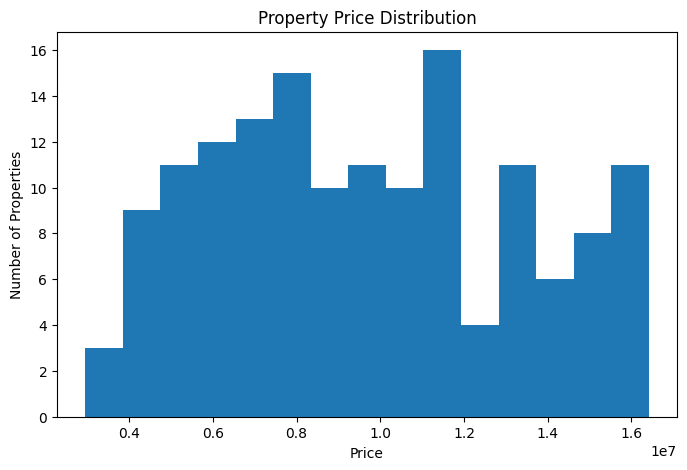


📊 PROPERTY ANALYTICS DASHBOARD
1. Average Property Price by Locality
2. Property Price Distribution
3. Crime Rate by Locality
4. Property Type Distribution
5. Bedrooms Distribution
6. Area vs Property Price
7. Metro Distance vs Property Price
8. Rental Yield Distribution
9. Exit


KeyboardInterrupt: Interrupted by user

In [ ]:
# ==========================================================
# PROPERTY ANALYTICS DASHBOARD
# ==========================================================

import matplotlib.pyplot as plt

while True:

    print("\n" + "="*60)
    print("📊 PROPERTY ANALYTICS DASHBOARD")
    print("="*60)

    print("1. Average Property Price by Locality")
    print("2. Property Price Distribution")
    print("3. Crime Rate by Locality")
    print("4. Property Type Distribution")
    print("5. Bedrooms Distribution")
    print("6. Area vs Property Price")
    print("7. Metro Distance vs Property Price")
    print("8. Rental Yield Distribution")
    print("9. Exit")

    choice = input("\nEnter Your Choice: ")

    # =====================================================
    # 1 PRICE BY LOCALITY
    # =====================================================

    if choice == "1":

        avg_price = df.groupby("locality_name")["price"].mean().sort_values()

        plt.figure(figsize=(10,5))
        plt.bar(avg_price.index, avg_price.values)

        plt.title("Average Property Price by Locality")
        plt.xlabel("Locality")
        plt.ylabel("Average Price (₹)")
        plt.xticks(rotation=45)

        plt.show()

    # =====================================================
    # 2 PRICE DISTRIBUTION
    # =====================================================

    elif choice == "2":

        plt.figure(figsize=(8,5))

        plt.hist(df["price"], bins=15)

        plt.title("Property Price Distribution")
        plt.xlabel("Price")
        plt.ylabel("Number of Properties")

        plt.show()

    # =====================================================
    # 3 CRIME RATE
    # =====================================================

    elif choice == "3":

        crime = df.groupby("locality_name")["crime_rate_index"].mean()

        plt.figure(figsize=(10,5))

        plt.bar(crime.index, crime.values)

        plt.title("Crime Rate by Locality")
        plt.xlabel("Locality")
        plt.ylabel("Crime Rate")

        plt.xticks(rotation=45)

        plt.show()

    # =====================================================
    # 4 PROPERTY TYPE
    # =====================================================

    elif choice == "4":

        property_type = df["property_type"].value_counts()

        plt.figure(figsize=(6,6))

        plt.pie(
            property_type.values,
            labels=property_type.index,
            autopct="%1.1f%%"
        )

        plt.title("Property Type Distribution")

        plt.show()

    # =====================================================
    # 5 BEDROOMS
    # =====================================================

    elif choice == "5":

        bedrooms = df["bedrooms"].value_counts().sort_index()

        plt.figure(figsize=(8,5))

        plt.bar(
            bedrooms.index.astype(str),
            bedrooms.values
        )

        plt.title("Bedrooms Distribution")
        plt.xlabel("Bedrooms")
        plt.ylabel("Number of Properties")

        plt.show()

    # =====================================================
    # 6 AREA VS PRICE
    # =====================================================

    elif choice == "6":

        plt.figure(figsize=(8,5))

        plt.scatter(
            df["area_sqft"],
            df["price"]
        )

        plt.title("Area vs Property Price")
        plt.xlabel("Area (sqft)")
        plt.ylabel("Price")

        plt.show()

    # =====================================================
    # 7 METRO VS PRICE
    # =====================================================

    elif choice == "7":

        plt.figure(figsize=(8,5))

        plt.scatter(
            df["metro_distance_km"],
            df["price"]
        )

        plt.title("Metro Distance vs Property Price")
        plt.xlabel("Metro Distance (km)")
        plt.ylabel("Price")

        plt.show()

    # =====================================================
    # 8 RENTAL YIELD
    # =====================================================

    elif choice == "8":

        if "rental_yield" in df.columns:

            plt.figure(figsize=(8,5))

            plt.hist(
                df["rental_yield"],
                bins=10
            )

            plt.title("Rental Yield Distribution")
            plt.xlabel("Rental Yield (%)")
            plt.ylabel("Number of Properties")

            plt.show()

        else:

            print("\n❌ Rental Yield column not found.")

    # =====================================================
    # EXIT
    # =====================================================

    elif choice == "9":

        print("\nReturning to Main Menu...")
        break

    else:

        print("\n❌ Invalid Choice")

In [ ]:
# ==========================================================
# AI PROPERTY ANALYZER
# ==========================================================

while True:

    print("\n" + "="*70)
    print("🏠 AI PROPERTY ANALYZER")
    print("="*70)

    print("1. Property Comparison")
    print("2. Future Growth Prediction")
    print("3. Property Report")
    print("4. Investment Analysis")
    print("5. Exit")

    choice = input("\nEnter Choice: ")

    # ======================================================
    # PROPERTY COMPARISON
    # ======================================================

    if choice == "1":

        id1 = input("Enter Property ID 1: ")
        id2 = input("Enter Property ID 2: ")

        p1 = df[df["property_id"] == id1]
        p2 = df[df["property_id"] == id2]

        if p1.empty or p2.empty:

            print("\n❌ Invalid Property ID")

        else:

            p1 = p1.iloc[0]
            p2 = p2.iloc[0]

            comparison = pd.DataFrame({

                "Feature":[
                    "Price",
                    "Area (sqft)",
                    "Bedrooms",
                    "Bathrooms",
                    "Crime Rate",
                    "Investment Score",
                    "Rental Yield",
                    "Overall AI Score"
                ],

                id1:[
                    p1["price"],
                    p1["area_sqft"],
                    p1["bedrooms"],
                    p1["bathrooms"],
                    p1["crime_rate_index"],
                    p1["investment_score"],
                    p1["rental_yield"],
                    p1["overall_ai_score"]
                ],

                id2:[
                    p2["price"],
                    p2["area_sqft"],
                    p2["bedrooms"],
                    p2["bathrooms"],
                    p2["crime_rate_index"],
                    p2["investment_score"],
                    p2["rental_yield"],
                    p2["overall_ai_score"]
                ]

            })

            print("\n")
            print(comparison)

            if p1["overall_ai_score"] > p2["overall_ai_score"]:

                print("\n🏆 Recommended :", id1)

            elif p2["overall_ai_score"] > p1["overall_ai_score"]:

                print("\n🏆 Recommended :", id2)

            else:

                print("\n⭐ Both Properties are Similar")

    # ======================================================
    # FUTURE GROWTH
    # ======================================================

    elif choice == "2":

        property_id = input("Enter Property ID : ")

        row = df[df["property_id"] == property_id]

        if row.empty:

            print("\n❌ Property Not Found")

        else:

            row = row.iloc[0]

            current = row["price"]

            growth = 0.08

            print("\n📈 FUTURE PRICE ESTIMATION")

            print("--------------------------------")

            print("Current Price : ₹{:,.0f}".format(current))

            print("After 1 Year : ₹{:,.0f}".format(current*((1+growth)**1)))

            print("After 3 Years : ₹{:,.0f}".format(current*((1+growth)**3)))

            print("After 5 Years : ₹{:,.0f}".format(current*((1+growth)**5)))

    # ======================================================
    # PROPERTY REPORT
    # ======================================================

    elif choice == "3":

        property_id = input("Enter Property ID : ")

        row = df[df["property_id"] == property_id]

        if row.empty:

            print("\n❌ Property Not Found")

        else:

            row = row.iloc[0]

            print("\n")
            print("="*60)
            print("🏠 PROPERTY REPORT")
            print("="*60)

            print("Property ID :", row["property_id"])
            print("Locality :", row["locality_name"])
            print("Property Type :", row["property_type"])
            print("Price : ₹{:,.0f}".format(row["price"]))
            print("Area :", row["area_sqft"],"sqft")
            print("Bedrooms :", row["bedrooms"])
            print("Bathrooms :", row["bathrooms"])
            print("Parking :", row["parking_spaces"])

            print("\n------ AI SCORES ------")

            print("Investment Score :", row["investment_score"])
            print("Family Score :", row["family_score"])
            print("Safety Score :", row["safety_score"])
            print("Rental Yield :", row["rental_yield"],"%")
            print("Overall AI Score :", row["overall_ai_score"])

            print("="*60)

    # ======================================================
    # INVESTMENT ANALYSIS
    # ======================================================

    elif choice == "4":

        property_id = input("Enter Property ID : ")

        row = df[df["property_id"] == property_id]

        if row.empty:

            print("\n❌ Property Not Found")

        else:

            row = row.iloc[0]

            print("\n")
            print("="*60)
            print("💰 INVESTMENT ANALYSIS")
            print("="*60)

            print("Investment Score :", row["investment_score"])
            print("Rental Yield :", row["rental_yield"],"%")
            print("Future Growth Score :", row["future_growth_score"])

            if row["overall_ai_score"] >= 90:

                print("\n⭐⭐⭐⭐⭐ Excellent Investment")

            elif row["overall_ai_score"] >= 80:

                print("\n⭐⭐⭐⭐ Very Good Investment")

            elif row["overall_ai_score"] >= 70:

                print("\n⭐⭐⭐ Good Investment")

            else:

                print("\n⭐⭐ Average Investment")

    # ======================================================
    # EXIT
    # ======================================================

    elif choice == "5":

        print("\n🙏 Returning to Main Menu...")

        break

    else:

        print("\n❌ Invalid Choice")